In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Nov 30 11:37:16 2023

@author: svenv
"""

# -*- coding: utf-8 -*-
"""
Created on Thu Nov 30 10:11:08 2023

@author: svenv
"""

import numpy as np
from scipy.linalg import solve
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

#%% Invariants
m, d, J = 3, 0.15, 0.05
phi, d_phi, dd_phi = 1, 2, 3
M = 2.7377

#%% Inverse Dynamics
def A_ivd(phi, d):
    return np.array([[-1, 0, 0], [0, -1, 0], [d*np.sin(phi), -d*np.cos(phi), 1]])

def b_ivd(phi, d_phi, dd_phi, m, d, J):
    return np.array([m*d*(np.cos(phi)*(d_phi)**2 + np.sin(phi)*dd_phi),
                     m*d*(np.sin(phi)*(d_phi)**2 - np.cos(phi)*dd_phi) - 9.81*m,
                     J*dd_phi])

def ivd(t, x, dd_phi, m=3, d=0.15, J=0.05):
    # x = [phi, d_phi]
    # Output = [d_phi, M]
    phi, d_phi = x
    A_ivd_mat = A_ivd(phi, d)
    b_ivd_mat = b_ivd(phi, d_phi, dd_phi, m, d, J)
    return [d_phi, solve(A_ivd_mat, b_ivd_mat)[2]]

A_ivd_mat = A_ivd(phi, d)
b_ivd_mat = b_ivd(phi, d_phi, dd_phi, m, d, J)

x_ivd = solve(A_ivd_mat, b_ivd_mat)

#%% Forward Dynamics
def A_fwd(phi, m, d, J):
    return np.array([[1, 0, m*d*np.sin(phi)], [0, 1, -m*d*np.cos(phi)], [d*np.sin(phi), -d*np.cos(phi), -J]])

def b_fwd(phi, d_phi, m, d, M):
    return np.array([-m*d*np.cos(phi)*(d_phi**2), -m*d*np.sin(phi)*(d_phi**2) + 9.81*m, -M])

A_fwd_mat = A_fwd(phi, m, d, J)
b_fwd_mat = b_fwd(phi, d_phi, m, d, M)

x_fwd = solve(A_fwd_mat, b_fwd_mat)

def fwd(t, x, M, m=3, d=0.15, J=0.05):
    phi, d_phi = x
    A_fwd_mat = A_fwd(phi, m, d, J)
    b_fwd_mat = b_fwd(phi, d_phi, m, d, M)
    return [d_phi, solve(A_fwd_mat, b_fwd_mat)[2]]



##  Numerical Integration Forward Dynamics

Text(0.5, 1.0, 'Conservation of Energy')

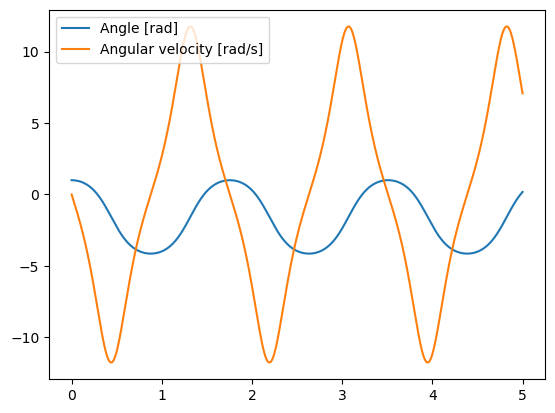

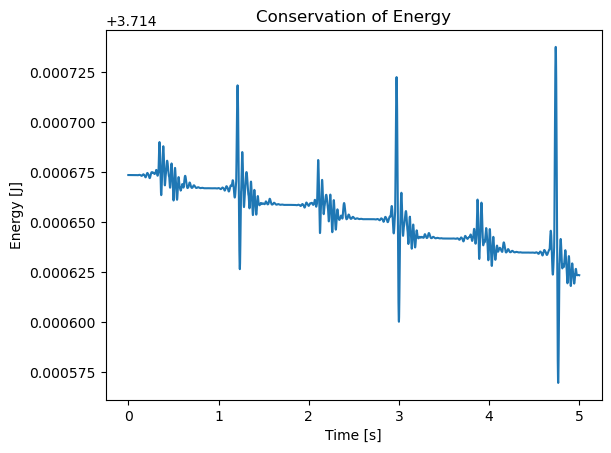

In [3]:
phi_init_fwd = [1, 0]
segdyn = solve_ivp(fwd, [0, 5], phi_init_fwd, args = [0], dense_output = True, rtol = 1e-6, atol = 1e-12)

time = np.arange(0, 5, 0.001)

plt.figure()
plt.plot(time, segdyn.sol(time)[0], label = 'Angle [rad]')
plt.plot(time, segdyn.sol(time)[1], label = 'Angular velocity [rad/s]')
plt.legend()

# phi_function = phi_init[0] + phi_init[1]*time + (1/2)*(segdyn.sol(time)[1])*time**2
# plt.figure()
# plt.plot(time, phi_function, label = 'Phi')
# plt.xlabel('Time [s]')
# plt.ylabel('Angle [rad]')

E = (1/2)*(m*d**2 + J)*segdyn.sol(time)[1]**2 + m*9.81*d*np.sin(segdyn.sol(time)[0])
plt.figure()
plt.plot(time, E)
plt.xlabel('Time [s]')
plt.ylabel('Energy [J]')
plt.title('Conservation of Energy')

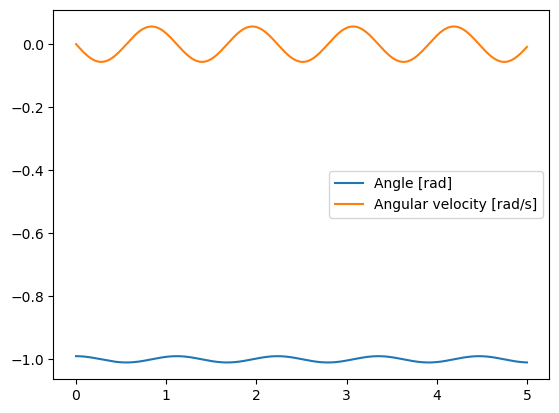

In [2]:
#%% Numerical Integration Inverse Dynamics
phi_init_ivd = [-1, 0]

peturb = 0.01
phi_init_ivd_peturbed = [-1 + peturb, 0]

def M_stat(phi, d, m=3):
    A = np.array([[-1, 0, 0], [0, -1, 0], [d*np.sin(phi), -d*np.cos(phi), 1]])
    b = np.array([0, -9.81*m, 0])
    return solve(A, b)[2]

def ivd_2_10(t, x, d=0.15, m=3):
    phi, d_phi = x
    A = np.array([[-1, 0, 0], [0, -1, 0], [d*np.sin(phi), -d*np.cos(phi), 1]])
    b = np.array([0, 0, 0])
    return [d_phi, solve(A, b)[2]]
    

M_stat = M = M_stat(phi_init_ivd[0], d)

segdyn_ivd = solve_ivp(fwd, [0, 5], phi_init_ivd_peturbed, args = [M_stat], dense_output = True)

time = np.arange(0, 5, 0.001)

plt.figure()
plt.plot(time, segdyn_ivd.sol(time)[0], label = 'Angle [rad]')
plt.plot(time, segdyn_ivd.sol(time)[1], label = 'Angular velocity [rad/s]')
plt.legend()